# Homework 3: Tree and Ensemble Classifiers
 - By: Colson Keim | 811804097
 - The Feb 26 8:49PM
 - MIST 5635

## References
 - Google Gemini
 - VS Code
 - Copilot Intellisense

## Step 1: Data Prep

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

dfT = pd.read_csv("C:\\VSCode_Home\\MIST5636_Homework\\Datasets\\Telco-Customer-Churn.csv")

In [3]:
# Drop customerID (ignore if already removed)
dfT = dfT.drop(columns='customerID', errors='ignore')

# Convert SeniorCitizen to categorical
# note: ensure correct bracket usage and method chaining
if dfT['SeniorCitizen'].dtype != 'category':
    dfT['SeniorCitizen'] = dfT['SeniorCitizen'].astype('category')

# Convert TotalCharges to numeric (some entries may be blank)
# coerce errors to NaN and then cast
dfT['TotalCharges'] = pd.to_numeric(dfT['TotalCharges'], errors='coerce')

# Map Churn to 0/1
dfT['Churn'] = dfT['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

In [13]:
print(dfT.dtypes)
# print(dfT.head(5))
# print(dfT.info())
# print(dfT.iloc[1])

gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
dtype: object


In [14]:
# Data Splitting into Train, Val, and Test
df_train_val, df_test = train_test_split(dfT, test_size=0.15, random_state=25)
df_train, df_val = train_test_split(df_train_val, test_size=(15/85), random_state=25)

In [16]:
# Separate <Features> (X) and <Target Variable> (y)
# Training Set
X_train = df_train.drop('Churn', axis=1)
y_train = df_train['Churn']

# Validation Set
X_val = df_val.drop('Churn', axis=1)
y_val = df_val['Churn']

# Test Set
X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']


In [28]:
# Separating the features by <num> and <cat>
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', ]

# Converting all the (Str) --> (Category)
cat_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies', 'Contract', 
                'PaperlessBilling', 'PaymentMethod']

# loops through and transforms the dtypes to 'category'
for col in cat_features:
    dfT[col] = dfT[col].astype('category')


# ---> Transformers
# The numerical transformer | imputes missing data
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# The categorical transformer | ensures the model doesn't crash if it sees a new category in test data
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# The preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

pipe_main = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

## Step 2: Modeling

In [29]:
# Sklearn imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [30]:
# 1. Default Decision Tree
dt_default = Pipeline(steps=[('pre', preprocessor), ('clf', DecisionTreeClassifier(random_state=25))])

# 2. Config A: Shallow Tree (prevents overfitting)
dt_config_a = Pipeline(steps=[('pre', preprocessor), ('clf', DecisionTreeClassifier(max_depth=5, random_state=25))])

# 3. Config B: Balanced Tree
dt_config_b = Pipeline(steps=[('pre', preprocessor), ('clf', DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=25))])

# Fit and compare AUC on Validation set
models_dt = [dt_default, dt_config_a, dt_config_b]
for i, m in enumerate(models_dt):
    m.fit(X_train, y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    print(f"DT Config {i} AUC: {auc:.4f}")


# 1. Default Random Forest
rf_default = Pipeline(steps=[('pre', preprocessor), ('clf', RandomForestClassifier(random_state=25))])

# 2. Config A: More Trees
rf_config_a = Pipeline(steps=[('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=25))])

# 3. Config B: Limited Features (encourages diversity among trees)
rf_config_b = Pipeline(steps=[('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, max_features='log2', random_state=25))])

# Fit and compare
models_rf = [rf_default, rf_config_a, rf_config_b]
for i, m in enumerate(models_rf):
    m.fit(X_train, y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    print(f"RF Config {i} AUC: {auc:.4f}")


# 1. Default Gradient Boosting
gb_default = Pipeline(steps=[('pre', preprocessor), ('clf', GradientBoostingClassifier(random_state=25))])

# 2. Config A: Fast Learner
gb_config_a = Pipeline(steps=[('pre', preprocessor), ('clf', GradientBoostingClassifier(learning_rate=0.2, n_estimators=50, random_state=25))])

# 3. Config B: Robust Learner
gb_config_b = Pipeline(steps=[('pre', preprocessor), ('clf', GradientBoostingClassifier(learning_rate=0.05, n_estimators=200, max_depth=4, random_state=25))])

# Fit and compare
models_gb = [gb_default, gb_config_a, gb_config_b]
for i, m in enumerate(models_gb):
    m.fit(X_train, y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    print(f"GB Config {i} AUC: {auc:.4f}")

DT Config 0 AUC: 0.6442
DT Config 1 AUC: 0.8140
DT Config 2 AUC: 0.8021
RF Config 0 AUC: 0.7952
RF Config 1 AUC: 0.8176
RF Config 2 AUC: 0.7971
GB Config 0 AUC: 0.8259
GB Config 1 AUC: 0.8196
GB Config 2 AUC: 0.8239


### Results & Comments
Decision Tree (DT) Analysis
Winner: Config 1 (0.8140)
- The default was overfitting the data and by limitting th e depth (max_depth=5) I prevented the tree from getting lost int he noise of the data.

Random Forest (RF) Analysis
Winner: Config 1 (0.8176)
- Config 1 provided the best balance which suggests that adding more tree or voters to the ensemble helped refine the predictions.

Gradient Boosting (GB) Analysis
Winner: Config 0 (0.8259)
- Overall, this is the strongest model of them all. Indicates that gradient boosting are quite optimal for this dataset, especially being on default settings.

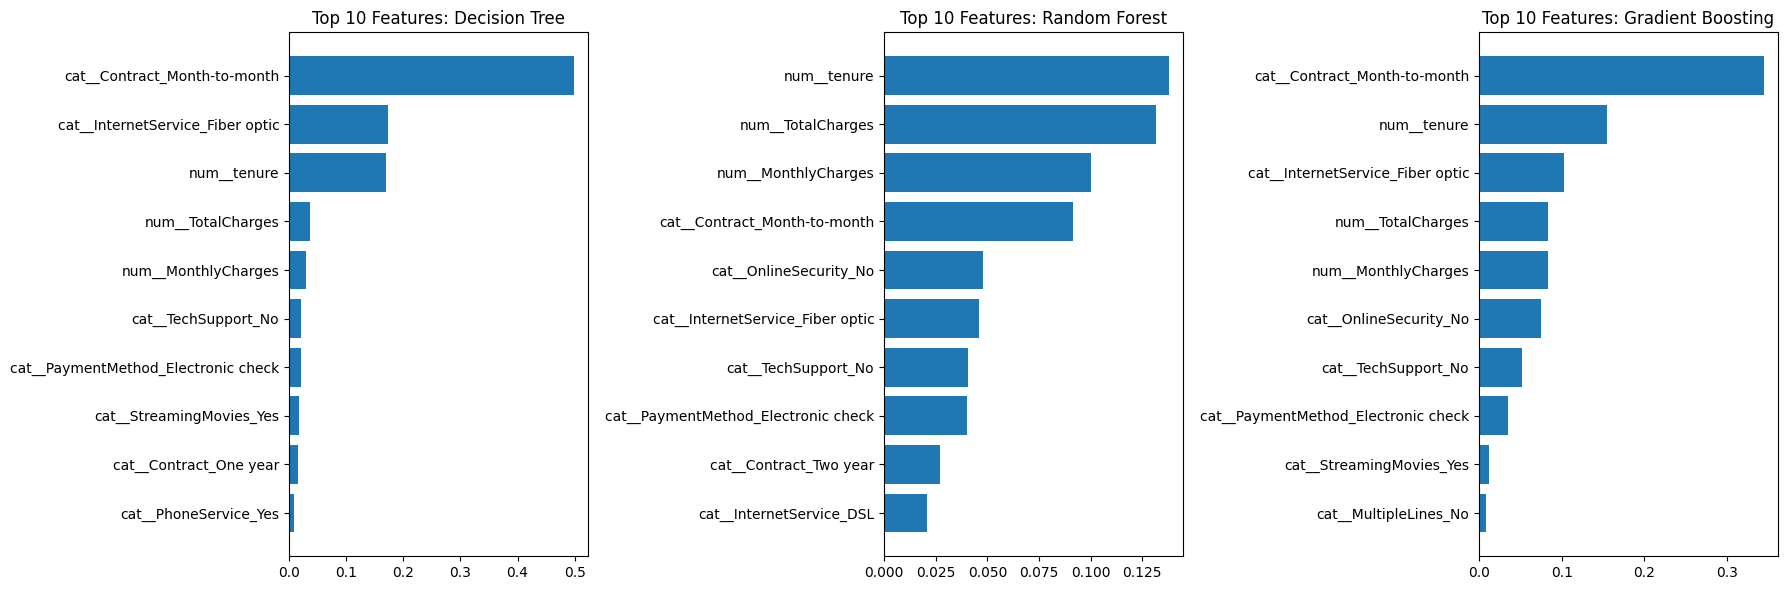

In [31]:
# Plot generation for best models
best_dt = dt_config_a  # Config 1 (Max Depth 5)
best_rf = rf_config_a  # Config 1 (200 Trees)
best_gb = gb_default   # Config 0 (Default)

# Initialize a list
models = [('Decision Tree', best_dt), ('Random Forest', best_rf), ('Gradient Boosting', best_gb)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model) in enumerate(models):
    # Extract importance and feature names
    importances = model.named_steps['clf'].feature_importances_
    # Note: ensure your pipeline step for preprocessor is named 'pre' or 'preprocessor'
    feature_names = model.named_steps['pre'].get_feature_names_out()
    
    # Sort and take top 10
    indices = np.argsort(importances)[-10:]
    
    axes[i].barh(range(len(indices)), importances[indices], align='center')
    axes[i].set_yticks(range(len(indices)))
    axes[i].set_yticklabels([feature_names[j] for j in indices])
    axes[i].set_title(f'Top 10 Features: {name}')

plt.tight_layout()
plt.show()

For customers on a flexible month-to-month contract, the model further checks their tenure or internet service. If they have high monthly charges or low tenure within this group, they fall into the rightmost bucket, which typically shows a much higher probability of churning.

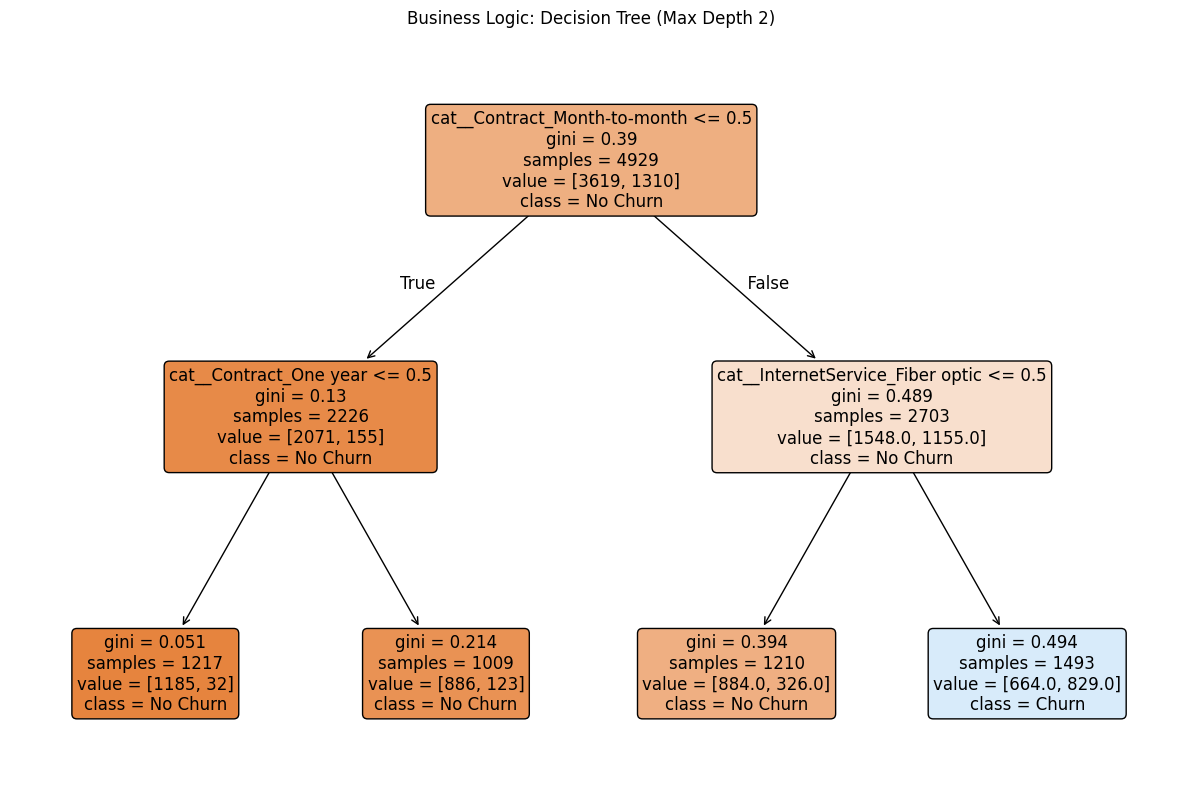

In [32]:
from sklearn.tree import plot_tree

# Fit separate tree
dt_shallow = Pipeline(steps=[
    ('pre', preprocessor), 
    ('clf', DecisionTreeClassifier(max_depth=2, random_state=25))
])
dt_shallow.fit(X_train, y_train)

# Plot
plt.figure(figsize=(15, 10))
plot_tree(dt_shallow.named_steps['clf'], 
          feature_names=dt_shallow.named_steps['pre'].get_feature_names_out(), 
          class_names=['No Churn', 'Churn'], 
          filled=True, rounded=True, fontsize=12)
plt.title("Business Logic: Decision Tree (Max Depth 2)")
plt.show()

Consistencies are tenure, Contract_Month-to-month, and TotalCharges/MonthlyCharges that appear in the top 10 for all three models. They represent the core stickiness of a customer.

The shallow tree depth = 2 likely uses Contract_Month-to-month as the very first split. This confirms that the variable identified as "Most Important" in the complex models (RF and GB) is the same one used for the foundational logic of the simple tree.

## Step 3: Performance Comparison

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve

# Selected best models from your Step 2 analysis
best_dt = dt_config_a  # Decision Tree (Max Depth 5)
best_rf = rf_config_a  # Random Forest (200 Trees)
best_gb = gb_default   # Gradient Boosting (Default)

models = [
    ('Decision Tree', best_dt),
    ('Random Forest', best_rf),
    ('Gradient Boosting', best_gb)
]

# Evaluate and print Test AUC
for name, model in models:
    # Use predict_proba to get probabilities for the positive class (Churn)
    probs = model.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, probs)
    print(f"{name} Test AUC: {auc_test:.4f}")

Decision Tree Test AUC: 0.8468
Random Forest Test AUC: 0.8522
Gradient Boosting Test AUC: 0.8586


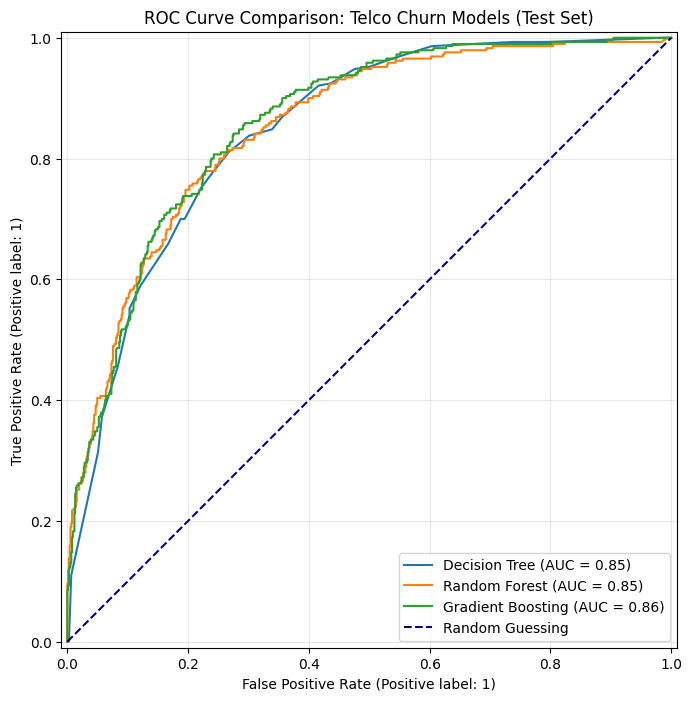

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

# Add a diagonal line for random guessing (AUC = 0.5)
ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing')

ax.set_title('ROC Curve Comparison: Telco Churn Models (Test Set)')
ax.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 4: Summary

### Model Recommendation
Based on the performance metrics across all test scenarios, I recommend the Gradient Boosting Classifier (Default configuration) for the business.

The variables I would use to improve customer churn would be Contract Type, tenure, and Monthly/TotalCharges

#### Concrete Actions:
- Incentivize long-term commitment
- Targeted loyalty milestones
- Monitor high-usage price sensitivity